In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#text processing
import re
import string

#sklearn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

import nltk
nltk.download("stopwords")
from nltk.corpus import stopwords
from collections import Counter
from wordcloud import WordCloud

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

import joblib

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hovan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
data = pd.read_csv('data/email_spam.csv', encoding='latin-1')

print("Overview dataset:")

print(f"\nShape: {data.shape[0]} rows × {data.shape[1]} columns")
print(f"\nColumns: {list(data.columns)}")

print("\nData Types:")
print(data.dtypes)

print("\nMissing Values:")
print(data.isnull().sum())

data.head(10)

Overview dataset:

Shape: 5572 rows × 5 columns

Columns: ['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']

Data Types:
v1            object
v2            object
Unnamed: 2    object
Unnamed: 3    object
Unnamed: 4    object
dtype: object

Missing Values:
v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
5,spam,FreeMsg Hey there darling it's been 3 week's n...,NaN,NaN,NaN
6,ham,Even my brother is not like to speak with me. ...,NaN,NaN,NaN
7,ham,As per your request 'Melle Melle (Oru Minnamin...,NaN,NaN,NaN
8,spam,WINNER!! As a valued network customer you have...,NaN,NaN,NaN
9,spam,Had your mobile 11 months or more? U R entitle...,NaN,NaN,NaN


<h1>Text Processing<h1>


In [3]:
#Data cleaning
data = data[['v1', 'v2']].copy()
data.columns = ['label', 'message']

#remove duplicate rows
before_dup = len(data)
data = data.drop_duplicates()
after_dup = len(data)

print(f"Duplicate rows remove: {before_dup - after_dup} / {before_dup}")

#encode label: ham = 0; spam = 1
le = LabelEncoder()
data['label_encoded'] = le.fit_transform(data['label'])

data.head()

Duplicate rows remove: 403 / 5572


,label,message,label_encoded
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [55]:
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = re.sub(r'<[^>]+>', '',text)
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.lower()
    text = text.translate(str.maketrans('','',string.punctuation))
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words and len(word) > 1]

    return ' '.join(tokens)

data['clean_message'] = data['message'].apply(preprocess_text)

data['message_length'] = data['message'].apply(len)
data['word_count'] = data['message'].apply(lambda x: len(x.split()))


data.head()
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5169 entries, 0 to 5571
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   label           5169 non-null   object
 1   message         5169 non-null   object
 2   label_encoded   5169 non-null   int32 
 3   clean_message   5169 non-null   object
 4   message_length  5169 non-null   int64 
 5   word_count      5169 non-null   int64 
dtypes: int32(1), int64(2), object(3)
memory usage: 262.5+ KB


In [5]:
X = data['clean_message']
y = data['label_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print(f"\nTraining set: {X_train.shape[0]:,} samples")
print(f"Testing set:  {X_test.shape[0]:,} samples")

print(f"\nTraining class distribution:")
for label, count in y_train.value_counts().items():
    label_name = 'ham' if label == 0 else 'spam'
    print(f"  - {label_name}: {count:,} ({100*count/len(y_train):.1f}%)")

print(f"\nTesting class distribution:")
for label, count in y_test.value_counts().items():
    label_name = 'ham' if label == 0 else 'spam'
    print(f"  - {label_name}: {count:,} ({100*count/len(y_test):.1f}%)")


Training set: 3,618 samples
Testing set:  1,551 samples

Training class distribution:
  - ham: 3,161 (87.4%)
  - spam: 457 (12.6%)

Testing class distribution:
  - ham: 1,355 (87.4%)
  - spam: 196 (12.6%)


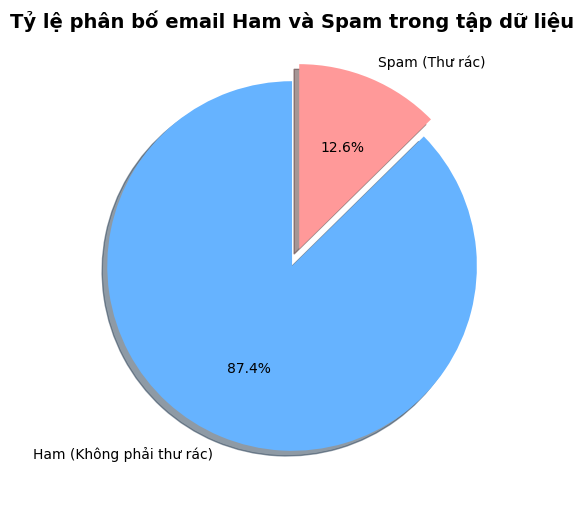

In [56]:
counts = data['label_encoded'].value_counts().sort_index()
plt.figure(figsize=(6, 6))

# Vẽ biểu đồ tròn
plt.pie(
    counts, 
    labels=['Ham (Không phải thư rác)', 'Spam (Thư rác)'], # Tên nhãn
    autopct='%1.1f%%', # Hiển thị phần trăm với 1 chữ số thập phân
    startangle=90,     # Xoay biểu đồ 90 độ cho đẹp
    colors=['#66b3ff', '#ff9999'], # Màu sắc cho Ham và Spam
    explode=(0, 0.1),  # Tách phần Spam ra một chút để nhấn mạnh
    shadow=True
)

plt.title('Tỷ lệ phân bố email Ham và Spam trong tập dữ liệu', fontsize=14, fontweight='bold')
plt.show()

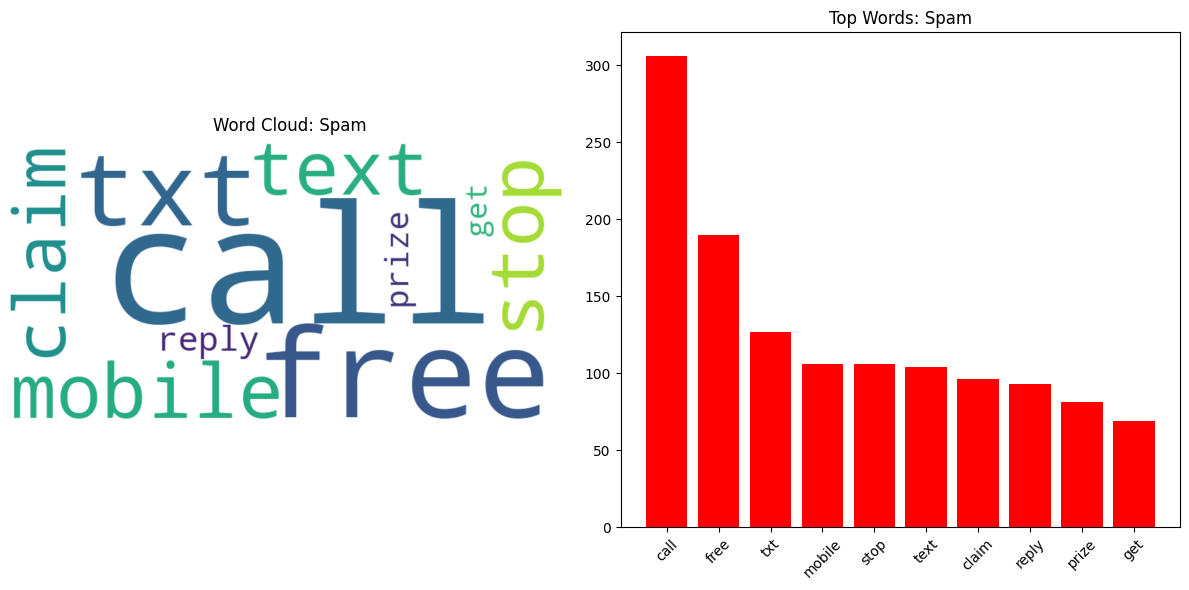

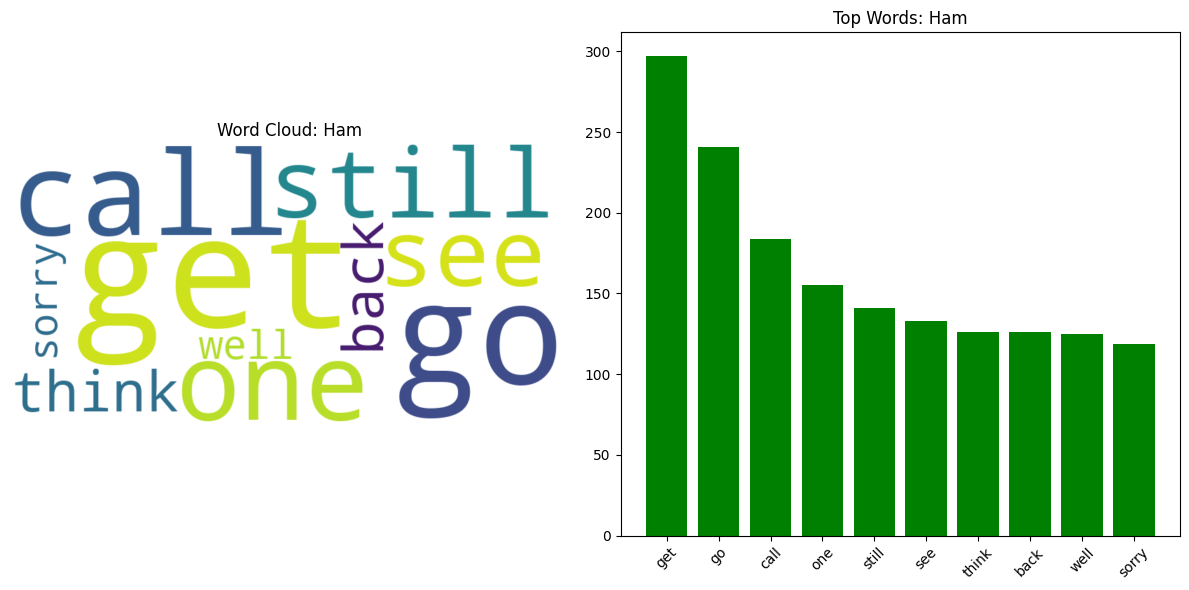

In [49]:

def plot_word_analysis(emails_series, title_suffix, color='orange'):
    # Tokenize and count
    words = ' '.join(emails_series).split()
    word_counts = Counter(words)
    most_common = word_counts.most_common(10)
    
    # Extract data for plotting
    words_list, counts = zip(*most_common)
    
    # Plotting
    plt.figure(figsize=(12, 6))
    
    # Word Cloud
    plt.subplot(1, 2, 1)
    # Generate from frequencies uses a dictionary
    wc = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(dict(most_common))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(f'Word Cloud: {title_suffix}')
    plt.axis('off')
    
    # Bar Chart
    plt.subplot(1, 2, 2)
    plt.bar(words_list, counts, color=color)
    plt.title(f'Top Words: {title_suffix}')
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()

plot_word_analysis(data[data['label'] == "spam"]['clean_message'], "Spam", color='red')
plot_word_analysis(data[data['label'] == "ham"]['clean_message'], "Ham", color='green')

In [8]:
print(" TF-IDF Vectorization")

# Fit TF-IDF on training data
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

# Fit and transform training data
X_train_tfidf = tfidf.fit_transform(X_train)

# Transform test data (using same vocabulary from training)
X_test_tfidf = tfidf.transform(X_test)

print(f"\nVocabulary size: {len(tfidf.vocabulary_):,}")
print(f"Training features shape: {X_train_tfidf.shape}")
print(f"Test features shape:     {X_test_tfidf.shape}")
print(f"\nTraining sparse matrix: {type(X_train_tfidf).__name__}")
print(f"Test sparse matrix:      {type(X_test_tfidf).__name__}")

# Fit SVD for visualization (reuse in SMOTE validation cell)
from sklearn.decomposition import TruncatedSVD
svd = TruncatedSVD(n_components=2, random_state=42)
svd.fit(X_train_tfidf)

 TF-IDF Vectorization

Vocabulary size: 5,000
Training features shape: (3618, 5000)
Test features shape:     (1551, 5000)

Training sparse matrix: csr_matrix
Test sparse matrix:      csr_matrix


TruncatedSVD(random_state=42)

<H1>TRAINING AND EVALUATE MODELS<h1>

<H4> Using logistic regression build from scratch and compare with Sklearn <H4>

Build from scratch

In [10]:
from models.logictisregression import LogisticRegressionM

In [11]:
modelLR = LogisticRegressionM(learning_rate=0.5, n_iters=3000)

X_train_lr = X_train_tfidf.toarray()
X_test_lr = X_test_tfidf.toarray()

y_train_lr = np.array(y_train)
y_test_lr = np.array(y_test)

modelLR.fit(X_train_lr, y_train_lr)

epoch = 0/3000: loss = 0.6931
epoch = 200/3000: loss = 0.3506
epoch = 400/3000: loss = 0.3248
epoch = 600/3000: loss = 0.3017
epoch = 800/3000: loss = 0.2814
epoch = 1000/3000: loss = 0.2635
epoch = 1200/3000: loss = 0.2478
epoch = 1400/3000: loss = 0.2340
epoch = 1600/3000: loss = 0.2218
epoch = 1800/3000: loss = 0.2110
epoch = 2000/3000: loss = 0.2013
epoch = 2200/3000: loss = 0.1927
epoch = 2400/3000: loss = 0.1849
epoch = 2600/3000: loss = 0.1778
epoch = 2800/3000: loss = 0.1714


(array([-0.05646223, -0.06281682, -0.04179925, ..., -0.03856048,
        -0.02530369, -0.08133804]),
 -2.2904259274813192)

In [12]:
print("\n     --- KẾT QUẢ ĐÁNH GIÁ CUỐI CÙNG TRÊN TẬP TEST ---")
modelLR.classification_Report(X_test_lr, y_test)


     --- KẾT QUẢ ĐÁNH GIÁ CUỐI CÙNG TRÊN TẬP TEST ---

                 precision     recall   f1-score    support

              0       0.98       0.98       0.98       1355
              1       0.87       0.85       0.86        196
       accuracy                             0.96       1551
      macro avg       0.92       0.92       0.92    1551.00


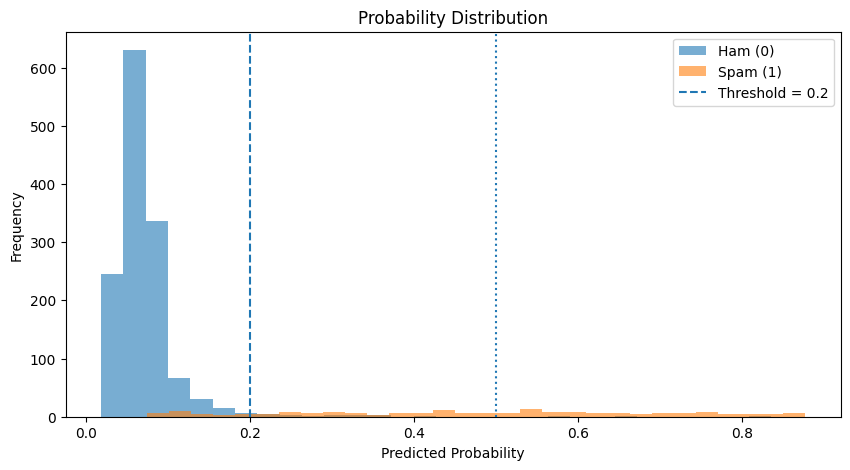

In [13]:
y_prob = modelLR.predict_proba(X_test_lr)

spam_probs = y_prob[y_test_lr == 1]
ham_probs = y_prob[y_test_lr == 0]

plt.figure(figsize=(10,5))

plt.hist(
    ham_probs,
    bins=30,
    alpha=0.6,
    label="Ham (0)"
)

plt.hist(
    spam_probs,
    bins=30,
    alpha=0.6,
    label="Spam (1)"
)

plt.axvline(
    x=0.2,
    linestyle="--",
    label="Threshold = 0.2"
)

plt.axvline(
    x=0.5,
    linestyle=":"
)

plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.title("Probability Distribution")
plt.legend()
plt.show()

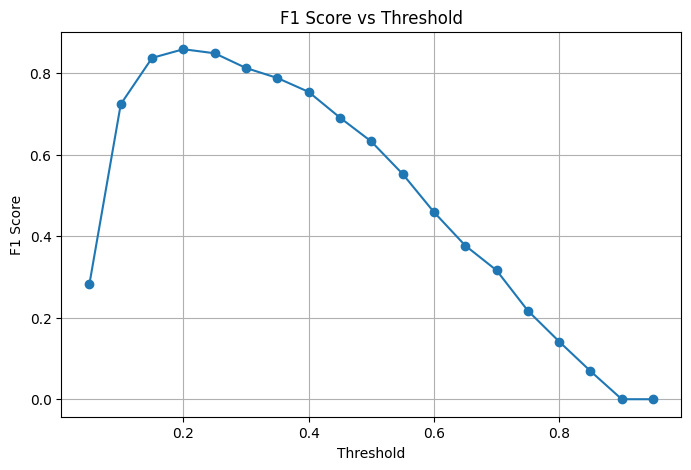

In [14]:

thresholds = np.arange(0.05, 1.0, 0.05)

f1_scores = []

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)

    f1 = f1_score(y_test_lr, y_pred)

    f1_scores.append(f1)

plt.figure(figsize=(8,5))

plt.plot(thresholds, f1_scores, marker="o")

plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score vs Threshold")

plt.grid(True)

plt.show()

In [15]:
test_emails = [
    # Spam
    "Unlock premium streaming access for just $1 today. Offer expires at midnight, subscribe immediately.",
    "Claim your exclusive travel voucher worth $750 by completing a short verification form.",
    "Act now to receive guaranteed approval for our instant cash advance program.",
    "You have been preselected for a cryptocurrency giveaway. Confirm your wallet details to participate.",
    "Final notice: complete payment within 24 hours to avoid service interruption and penalty charges.",

    # Ham
    "Reminder: your dental appointment is scheduled for next Tuesday at 2:30 PM. Reply if you need to reschedule.",
    "The development server has been updated. Please pull the latest changes before continuing work.",
    "Your library books are due in three days. Visit the portal if you wish to renew them.",
    "Thanks for your purchase. Your receipt and warranty information are attached for your records.",
    "The monthly team lunch has been moved to Friday because several members are traveling this week."
]

true_labels = [
    1, 1, 1, 1, 1,   # spam
    0, 0, 0, 0, 0    # ham
]

clean_emails = []

for email in test_emails:
    clean_email = preprocess_text(email)
    clean_emails.append(clean_email)

X_new = tfidf.transform(clean_emails).toarray()

predictions = modelLR.predict(X_new)


for i in range(len(test_emails)):
    actual = "Spam" if true_labels[i] == 1 else "Ham"
    predicted = "Spam" if predictions[i] == 1 else "Ham"

    print("Email:", test_emails[i])
    print("Actual:", actual)
    print("Predicted:", predicted)
    print("-" * 80)

Email: Unlock premium streaming access for just $1 today. Offer expires at midnight, subscribe immediately.
Actual: Spam
Predicted: Ham
--------------------------------------------------------------------------------
Email: Claim your exclusive travel voucher worth $750 by completing a short verification form.
Actual: Spam
Predicted: Spam
--------------------------------------------------------------------------------
Email: Act now to receive guaranteed approval for our instant cash advance program.
Actual: Spam
Predicted: Spam
--------------------------------------------------------------------------------
Email: You have been preselected for a cryptocurrency giveaway. Confirm your wallet details to participate.
Actual: Spam
Predicted: Ham
--------------------------------------------------------------------------------
Email: Final notice: complete payment within 24 hours to avoid service interruption and penalty charges.
Actual: Spam
Predicted: Ham
----------------------------------

Sklearn

In [16]:
from sklearn.linear_model import LogisticRegression

In [17]:
sklearn_lr = LogisticRegression(
    max_iter=3000
)

sklearn_lr.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=3000)

In [18]:
y_pred_sklearn = sklearn_lr.predict(X_test_tfidf)

print("--- SKLEARN LOGISTIC REGRESSION ---")
print(classification_report(y_test, y_pred_sklearn))
print("Accuracy:", accuracy_score(y_test, y_pred_sklearn))

--- SKLEARN LOGISTIC REGRESSION ---
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      1355
           1       0.98      0.61      0.75       196

    accuracy                           0.95      1551
   macro avg       0.96      0.80      0.86      1551
weighted avg       0.95      0.95      0.94      1551

Accuracy: 0.9484203739522888


<H3>COMPARE<H3>

In [19]:
print("My Logistic:")
modelLR.classification_Report(X_test_lr, y_test_lr)

print("\n\nSklearn Logistic:")
print(classification_report(y_test, y_pred_sklearn))

My Logistic:

                 precision     recall   f1-score    support

              0       0.98       0.98       0.98       1355
              1       0.87       0.85       0.86        196
       accuracy                             0.96       1551
      macro avg       0.92       0.92       0.92    1551.00


Sklearn Logistic:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      1355
           1       0.98      0.61      0.75       196

    accuracy                           0.95      1551
   macro avg       0.96      0.80      0.86      1551
weighted avg       0.95      0.95      0.94      1551



<H1>Naive Bayes<h1>

From scratch

In [23]:
from models.naive_bayes import NaiveBayes

In [24]:
model_nb = NaiveBayes()

X_train_nb = X_train_tfidf.toarray()
X_test_nb = X_test_tfidf.toarray()

y_train_nb = np.array(y_train)
y_test_nb = np.array(y_test)

In [25]:
model_nb = NaiveBayes()

model_nb.fit(X_train_nb, np.array(y_train_nb))

y_pred_nb = model_nb.predict(X_test_nb)

c:\Users\hovan\OneDrive\Desktop\practice1\models\naive_bayes.py:32: RuntimeWarning: divide by zero encountered in log
  np.log(self.gaussian(x, self.mean[c], self.var[c]))


In [26]:
print("--- NAIVE BAYES FROM SCRATCH---")
print(classification_report(y_test_nb, y_pred_nb))

--- NAIVE BAYES FROM SCRATCH---
              precision    recall  f1-score   support

           0       0.95      0.96      0.96      1355
           1       0.73      0.68      0.70       196

    accuracy                           0.93      1551
   macro avg       0.84      0.82      0.83      1551
weighted avg       0.93      0.93      0.93      1551



In [27]:
for email in test_emails:
    clean_email = preprocess_text(email)
    clean_emails.append(clean_email)

X_new = tfidf.transform(clean_emails).toarray()

predictions = model_nb.predict(X_new)


for i in range(len(test_emails)):
    actual = "Spam" if true_labels[i] == 1 else "Ham"
    predicted = "Spam" if predictions[i] == 1 else "Ham"

    print("Email:", test_emails[i])
    print("Actual:", actual)
    print("Predicted:", predicted)
    print("-" * 80)

Email: Unlock premium streaming access for just $1 today. Offer expires at midnight, subscribe immediately.
Actual: Spam
Predicted: Spam
--------------------------------------------------------------------------------
Email: Claim your exclusive travel voucher worth $750 by completing a short verification form.
Actual: Spam
Predicted: Ham
--------------------------------------------------------------------------------
Email: Act now to receive guaranteed approval for our instant cash advance program.
Actual: Spam
Predicted: Ham
--------------------------------------------------------------------------------
Email: You have been preselected for a cryptocurrency giveaway. Confirm your wallet details to participate.
Actual: Spam
Predicted: Ham
--------------------------------------------------------------------------------
Email: Final notice: complete payment within 24 hours to avoid service interruption and penalty charges.
Actual: Spam
Predicted: Ham
-----------------------------------

c:\Users\hovan\OneDrive\Desktop\practice1\models\naive_bayes.py:32: RuntimeWarning: divide by zero encountered in log
  np.log(self.gaussian(x, self.mean[c], self.var[c]))


Sklearn

In [28]:
from sklearn.naive_bayes import MultinomialNB

mnb = MultinomialNB()

mnb.fit(X_train_tfidf, y_train)

y_pred_mnb = mnb.predict(X_test_tfidf)

print(classification_report(y_test, y_pred_mnb))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98      1355
           1       0.99      0.70      0.82       196

    accuracy                           0.96      1551
   macro avg       0.98      0.85      0.90      1551
weighted avg       0.96      0.96      0.96      1551



COMPARE

In [29]:
print("--- NAIVE BAYES FROM SCRATCH---")
print(classification_report(y_test_nb, y_pred_nb))

print("\n--- NAIVE BAYES FROM SKLEARN---")
print(classification_report(y_test, y_pred_mnb))

--- NAIVE BAYES FROM SCRATCH---
              precision    recall  f1-score   support

           0       0.95      0.96      0.96      1355
           1       0.73      0.68      0.70       196

    accuracy                           0.93      1551
   macro avg       0.84      0.82      0.83      1551
weighted avg       0.93      0.93      0.93      1551


--- NAIVE BAYES FROM SKLEARN---
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      1355
           1       0.99      0.70      0.82       196

    accuracy                           0.96      1551
   macro avg       0.98      0.85      0.90      1551
weighted avg       0.96      0.96      0.96      1551



<h1> SVM

from scratch

In [30]:
from models.svm import LinearSVM

In [31]:
X_train_svm = X_train_tfidf.toarray()
X_test_svm = X_test_tfidf.toarray()

y_train_svm = np.array(y_train)
y_test_svm = np.array(y_test)

In [32]:
svm_model = LinearSVM(
    learning_rate=0.05,
    lambda_param=0.0001,
    epochs=5000
)


svm_model.fit(X_train_svm, y_train_svm)

Epoch 0: Loss = 1.0000
Epoch 500: Loss = 0.8460
Epoch 1000: Loss = 0.6935
Epoch 1500: Loss = 0.5498
Epoch 2000: Loss = 0.4267
Epoch 2500: Loss = 0.3414
Epoch 3000: Loss = 0.2877
Epoch 3500: Loss = 0.2534
Epoch 4000: Loss = 0.2289
Epoch 4500: Loss = 0.2104


In [33]:
y_pred_svm = svm_model.predict(X_test_svm)

print("--- SVM FROM SCRATCH ---")
print(classification_report(y_test_svm, y_pred_svm))

--- SVM FROM SCRATCH ---
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1355
           1       0.87      0.85      0.86       196

    accuracy                           0.97      1551
   macro avg       0.92      0.92      0.92      1551
weighted avg       0.96      0.97      0.97      1551



In [34]:
for email in test_emails:
    clean_email = preprocess_text(email)
    clean_emails.append(clean_email)

X_new = tfidf.transform(clean_emails).toarray()

predictions = svm_model.predict(X_new)

for i in range(len(test_emails)):
    actual = "Spam" if true_labels[i] == 1 else "Ham"
    predicted = "Spam" if predictions[i] == 1 else "Ham"

    print("Email:", test_emails[i])
    print("Actual:", actual)
    print("Predicted:", predicted)
    print("-" * 80)

Email: Unlock premium streaming access for just $1 today. Offer expires at midnight, subscribe immediately.
Actual: Spam
Predicted: Ham
--------------------------------------------------------------------------------
Email: Claim your exclusive travel voucher worth $750 by completing a short verification form.
Actual: Spam
Predicted: Spam
--------------------------------------------------------------------------------
Email: Act now to receive guaranteed approval for our instant cash advance program.
Actual: Spam
Predicted: Spam
--------------------------------------------------------------------------------
Email: You have been preselected for a cryptocurrency giveaway. Confirm your wallet details to participate.
Actual: Spam
Predicted: Ham
--------------------------------------------------------------------------------
Email: Final notice: complete payment within 24 hours to avoid service interruption and penalty charges.
Actual: Spam
Predicted: Ham
----------------------------------

SKLEARN

In [35]:
from sklearn.svm import LinearSVC

sk_svm = LinearSVC()

sk_svm.fit(X_train_tfidf, y_train)

y_pred_sk_svm = sk_svm.predict(X_test_tfidf)

print("--- SKLEARN SVM ---")
print(classification_report(y_test, y_pred_sk_svm))

--- SKLEARN SVM ---
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1355
           1       0.99      0.83      0.90       196

    accuracy                           0.98      1551
   macro avg       0.98      0.91      0.94      1551
weighted avg       0.98      0.98      0.98      1551



In [36]:
# Scratch SVM
y_pred_svm_scratch = svm_model.predict(X_test_svm)

# Sklearn SVM
y_pred_svm_sklearn = sk_svm.predict(X_test_tfidf)

metrics_name = ["Accuracy", "Precision", "Recall", "F1-score"]

scratch_scores = [
    accuracy_score(y_test_svm, y_pred_svm_scratch),
    precision_score(y_test_svm, y_pred_svm_scratch),
    recall_score(y_test_svm, y_pred_svm_scratch),
    f1_score(y_test_svm, y_pred_svm_scratch)
]

sklearn_scores = [
    accuracy_score(y_test, y_pred_svm_sklearn),
    precision_score(y_test, y_pred_svm_sklearn),
    recall_score(y_test, y_pred_svm_sklearn),
    f1_score(y_test, y_pred_svm_sklearn)
]

print("Scratch:", scratch_scores)
print("Sklearn:", sklearn_scores)

Scratch: [0.965183752417795, 0.8697916666666666, 0.8520408163265306, 0.8608247422680413]
Sklearn: [0.97678916827853, 0.9878048780487805, 0.826530612244898, 0.9]


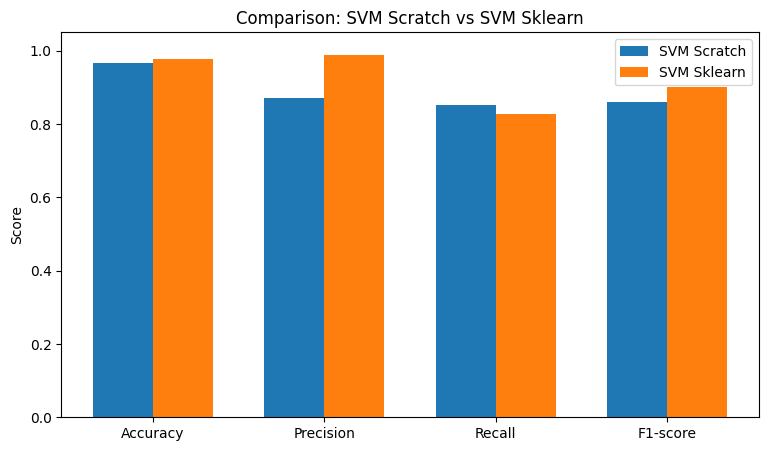

In [37]:
x = np.arange(len(metrics_name))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(x - width/2, scratch_scores, width, label="SVM Scratch")
plt.bar(x + width/2, sklearn_scores, width, label="SVM Sklearn")

plt.xticks(x, metrics_name)
plt.ylim(0, 1.05)

plt.ylabel("Score")
plt.title("Comparison: SVM Scratch vs SVM Sklearn")
plt.legend()

plt.show()

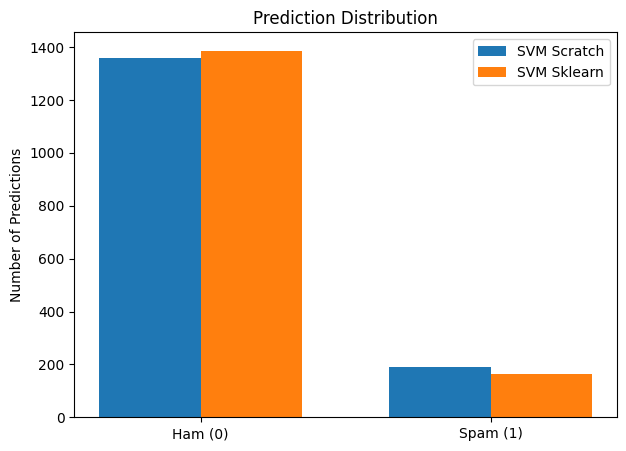

In [38]:
labels = ["Ham (0)", "Spam (1)"]

scratch_count_full = [
    np.sum(y_pred_svm_scratch == 0),
    np.sum(y_pred_svm_scratch == 1)
]

sklearn_count_full = [
    np.sum(y_pred_svm_sklearn == 0),
    np.sum(y_pred_svm_sklearn == 1)
]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(7, 5))

plt.bar(x - width/2, scratch_count_full, width, label="SVM Scratch")
plt.bar(x + width/2, sklearn_count_full, width, label="SVM Sklearn")

plt.xticks(x, labels)
plt.ylabel("Number of Predictions")
plt.title("Prediction Distribution")
plt.legend()

plt.show()

In [ ]:
# Lưu mô hình đã huấn luyện
joblib.dump(modelLR, "phanloaiemail.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")
joblib.dump(svm_model, "svm_model.pkl")
joblib.dump(model_nb,    "naive_bayes_model.pkl")
print("Mô hình đã được lưu!")

Mô hình đã được lưu!


In [40]:
!ngrok config add-authtoken "3EaTBGrhOhc85JWX0GIBusHAPEp_VwiHhXGFK51FFksUtMka"

Authtoken saved to configuration file: C:\Users\hovan\AppData\Local\ngrok\ngrok.yml


In [ ]:
# Chạy app (Run App)
import subprocess, time
from pyngrok import ngrok

ngrok.kill()

# Start Streamlit in background first
subprocess.Popen(["streamlit", "run", "app.py", "--server.headless", "true"])
time.sleep(3)  # Wait for Streamlit to start

# Then connect ngrok
public_url = ngrok.connect(8501)
print("Public URL:", public_url)

Public URL: NgrokTunnel: "https://deploy-deprive-establish.ngrok-free.dev" -> "http://localhost:8501"


t=2026-06-03T16:07:21+0700 lvl=eror msg="session closed, starting reconnect loop" obj=tunnels.session obj=csess id=ca6f998b6dc6 err="read tcp [2402:800:63b7:f293:8906:7ca1:df18:80d3]:56240->[2600:1f16:d83:1200:ed02:c6b4:e6d5:3cb2]:443: wsarecv: An established connection was aborted by the software in your host machine."
t=2026-06-03T16:07:40+0700 lvl=eror msg="heartbeat timeout, terminating session" obj=tunnels.session obj=csess id=c6f0ae945e25 clientid=857bf7f60ea31b5c844cd622749feda7
t=2026-06-03T16:43:13+0700 lvl=eror msg="session closed, starting reconnect loop" obj=tunnels.session obj=csess id=ca6f998b6dc6 err="read EOF from remote peer"
t=2026-06-03T16:43:14+0700 lvl=eror msg="heartbeat timeout, terminating session" obj=tunnels.session obj=csess id=faff31f68e10 clientid=857bf7f60ea31b5c844cd622749feda7
t=2026-06-03T16:49:41+0700 lvl=eror msg="heartbeat timeout, terminating session" obj=tunnels.session obj=csess id=fccc369a8137 clientid=857bf7f60ea31b5c844cd622749feda7
t=2026-06-0